# 📂 Métricas de avaliação

**Professora:** Dra. Isadora Garcia Ferrão

📧 [instagram](https://www.instagram.com/isadora.ferrao/)

🌐 [linkedin](https://www.linkedin.com/in/isadora-ferrao/)

---

# **Avaliação de modelos em ciência de dados**

Treinar um modelo de machine learning é apenas uma parte do problema.

A questão realmente importante é:

**Como sabemos se o modelo é bom?**

Ou ainda:

- O modelo está **superajustado (overfitting)**?
- O modelo está **subajustado (underfitting)**?
- O erro é **aceitável para o problema**?
- Como **comparar modelos diferentes**?

---

Nesta aula veremos métricas para três tipos de problemas:

1. **Regressão** - prever valores contínuos
2. **Classificação** - prever categorias
3. **Agrupamento (Clustering)** - descobrir padrões nos dados

---

# Erro vs Resíduo

Considere um modelo que tenta prever um valor real.

Denotamos:

- $y_i$ : valor observado
- $\hat{y}_i$ : valor predito pelo modelo

O **erro verdadeiro** é definido como:

$$
\varepsilon_i = y_i - \hat{y}_i
$$

Entretanto, o erro verdadeiro **não é observável diretamente**, pois o modelo é apenas uma aproximação do processo gerador de dados.

Na prática utilizamos o **resíduo**.

O **resíduo** é definido como:

$$
e_i = y_i - \hat{y}_i
$$

Ou seja:

> O **resíduo é uma estimativa observada do erro**.

---

## Interpretação

Se o modelo estiver bem ajustado, esperamos que:

- os resíduos tenham **média próxima de zero**
- os resíduos não tenham **padrões estruturais**
- a variância seja aproximadamente **constante**

# Modelos de regressão

Vamos utilizar o dataset **House Prices**, que contém características de imóveis e seus preços.

Nosso objetivo será:

> prever o preço de uma casa a partir de suas características.

Esse é um problema clássico de **regressão**.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df = df.dropna()

X = df.drop("median_house_value", axis=1)

X = pd.get_dummies(X)

y = df["median_house_value"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo de regressão linear

A regressão linear assume que a variável resposta pode ser modelada como:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p + \varepsilon
$$

onde:

- $y$ é a variável resposta
- $x_j$ são as variáveis explicativas
- $\beta_j$ são os coeficientes do modelo
- $\varepsilon$ representa o erro aleatório

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Resíduos do modelo

Após treinar o modelo, podemos calcular os resíduos:

$$
e_i = y_i - \hat{y}_i
$$

Esses resíduos são fundamentais para diagnosticar a qualidade do ajuste do modelo.

In [ ]:
residuos = y_test - y_pred

# Diagnóstico gráfico dos resíduos

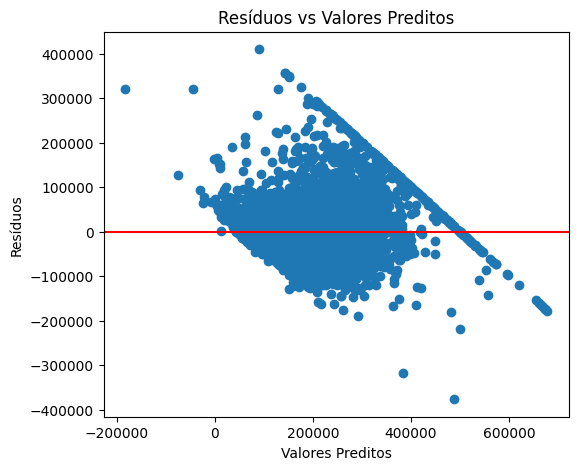

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuos)

plt.axhline(0, color='red')

plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")

plt.title("Resíduos vs Valores Preditos")

plt.show()

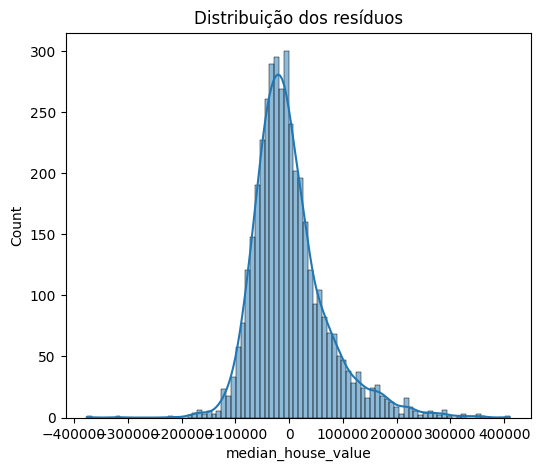

In [ ]:
plt.figure(figsize=(6,5))

sns.histplot(residuos, kde=True)

plt.title("Distribuição dos resíduos")

plt.show()

# Mean Absolute Error (MAE)

O erro absoluto médio é definido como:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Ele mede o erro médio em **unidades da variável resposta**.

Interpretação:

> Em média, o modelo erra aproximadamente **MAE unidades**.

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

mae

50413.43330810045

# Mean Squared Error (MSE)

O erro quadrático médio é definido como:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Diferentemente do MAE, o MSE penaliza mais fortemente erros grandes.

Isso ocorre porque o erro é elevado ao quadrado.

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

mse

4802173538.604137

# Root Mean Squared Error (RMSE)

O RMSE é simplesmente a raiz quadrada do MSE:

$$
RMSE = \sqrt{MSE}
$$

Isso permite interpretar o erro na **mesma unidade da variável resposta**.

In [ ]:
rmse = np.sqrt(mse)

rmse

np.float64(69297.71669113015)

# Mean Absolute Percentage Error (MAPE)

O erro percentual absoluto médio é definido como:

$$
MAPE = \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|
$$

Essa métrica expressa o erro em **percentual**.

In [ ]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

mape

np.float64(28.5959744711941)

# Coeficiente de Determinação

O coeficiente de determinação é definido como:

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

onde

$$
SS_{res} = \sum (y_i - \hat{y}_i)^2
$$

$$
SS_{tot} = \sum (y_i - \bar{y})^2
$$

Interpretação:

- $R^2 = 1$ → ajuste perfeito
- $R^2 = 0$ → modelo não explica a variabilidade

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

r2

0.6488402154432009

In [ ]:
metrics = pd.DataFrame({
    "MAE":[mae],
    "MSE":[mse],
    "RMSE":[rmse],
    "MAPE":[mape],
    "R2":[r2]
})

metrics

,MAE,MSE,RMSE,MAPE,R2
0,50413.433308,4.802174e+09,69297.716691,28.595974,0.64884


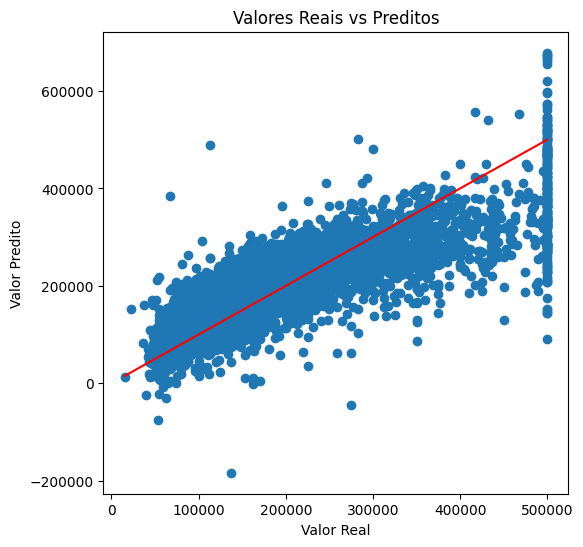

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")

plt.title("Valores Reais vs Preditos")

plt.show()

# Avaliação de Modelos de Classificação

Em muitos problemas de ciência de dados o objetivo não é prever um valor contínuo, mas sim **classificar observações em categorias**.

Exemplos:

- fraude vs não fraude
- churn vs não churn
- doença vs saudável
- spam vs não spam

Formalmente, queremos prever uma variável categórica:

$$
y \in \{0,1\}
$$

ou, mais geralmente,

$$
y \in \{1,2,...,K\}
$$

Para avaliar modelos de classificação utilizamos métricas baseadas nas **comparações entre classes reais e classes previstas**.

### Vamos transformar o dataset de regressão em classificação.

Objetivo:

> Classificar casas em preço alto vs preço baixo

In [ ]:
df_class = df.copy()

df_class["HighPrice"] = (
    df_class["median_house_value"] >
    df_class["median_house_value"].median()
).astype(int)

df_class.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,HighPrice
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,1


In [ ]:
X = df_class.drop(["median_house_value","HighPrice"], axis=1)

X = pd.get_dummies(X)

y = df_class["HighPrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Regressão Logística

A regressão logística modela a probabilidade de pertencimento a uma classe.

A função utilizada é a função logística:

$$
P(Y=1|X) =
\frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + ... + \beta_px_p)}}
$$

O modelo estima a probabilidade de um evento ocorrer.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Matriz de Confusão

A matriz de confusão compara:

- valores reais
- valores previstos

Ela possui quatro componentes fundamentais:

| | Predito Negativo | Predito Positivo |
|---|---|---|
| Real Negativo | TN | FP |
| Real Positivo | FN | TP |

onde:

- **TP**: True Positive
- **TN**: True Negative
- **FP**: False Positive
- **FN**: False Negative

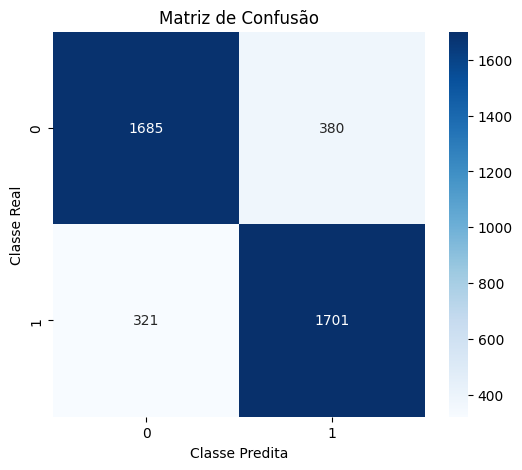

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.title("Matriz de Confusão")

plt.show()

# Acurácia

A acurácia mede a proporção total de previsões corretas.

$$
Accuracy =
\frac{TP + TN}{TP + TN + FP + FN}
$$

Interpretação:

> Qual fração das previsões do modelo está correta?

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.8284805480792757

# Precision

Precision responde à pergunta:

> Das previsões positivas feitas pelo modelo, quantas estavam corretas?

$$
Precision =
\frac{TP}{TP + FP}
$$

Essa métrica é especialmente importante quando **falsos positivos são custosos**.

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

precision

0.8173954829408938

# Recall

Recall responde à pergunta:

> Dos casos positivos reais, quantos foram identificados pelo modelo?

$$
Recall =
\frac{TP}{TP + FN}
$$

Essa métrica é fundamental quando **falsos negativos são perigosos**.

Exemplo clássico: diagnóstico médico.

In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

recall

0.841246290801187

# F1 Score

O F1-score combina **precision** e **recall** em uma única métrica.

Ele é definido como a média harmônica entre as duas métricas.

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

O F1-score é útil quando queremos equilibrar:

- falsos positivos
- falsos negativos

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

f1

0.8291494028759444

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      2065
           1       0.82      0.84      0.83      2022

    accuracy                           0.83      4087
   macro avg       0.83      0.83      0.83      4087
weighted avg       0.83      0.83      0.83      4087



# Conclusões

Cada métrica responde a uma pergunta diferente:

- **Accuracy** → qual a taxa geral de acertos?
- **Precision** → quantas previsões positivas estavam corretas?
- **Recall** → quantos positivos foram detectados?
- **F1-score** → equilíbrio entre precision e recall.

A escolha da métrica depende sempre do **contexto do problema**.

---

# Avaliação de Modelos de Agrupamento

Diferentemente de regressão e classificação, no **clustering** não temos rótulos verdadeiros.

Ou seja:

- não sabemos a resposta correta
- não sabemos quantos grupos realmente existem

O objetivo do clustering é **descobrir padrões estruturais nos dados**.

Exemplos:

- segmentação de clientes
- padrões de consumo
- agrupamento de documentos
- segmentação de imagens

Como não temos rótulos verdadeiros, precisamos avaliar os clusters usando **critérios internos**.

Esses critérios geralmente medem duas propriedades:

1. **Coesão** - quão próximos estão os pontos dentro de um cluster  
2. **Separação** - quão distantes estão clusters diferentes

# Preparando dados para clustering

Vamos utilizar o mesmo dataset usado anteriormente (California Housing).

Para clustering, selecionaremos apenas algumas variáveis numéricas:

- median_income
- housing_median_age
- total_rooms

Antes de aplicar algoritmos de agrupamento, é importante **padronizar as variáveis**, pois muitas métricas utilizam distância euclidiana.
----

# Within Sum of Squares (WSS)

O WSS mede a variabilidade dentro dos clusters.

$$
WSS =
\sum_{k=1}^{K}
\sum_{i \in C_k}
||x_i - \mu_k||^2
$$

Interpretação:

- valores menores indicam clusters mais compactos

In [ ]:
from sklearn.cluster import KMeans

wss = []

K = range(1,10)

for k in K:

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_cluster)

    wss.append(model.inertia_)

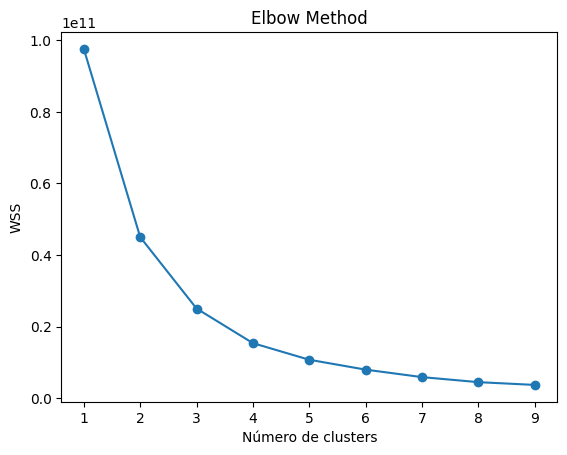

In [ ]:
plt.plot(K, wss, marker='o')

plt.xlabel("Número de clusters")
plt.ylabel("WSS")

plt.title("Elbow Method")

plt.show()

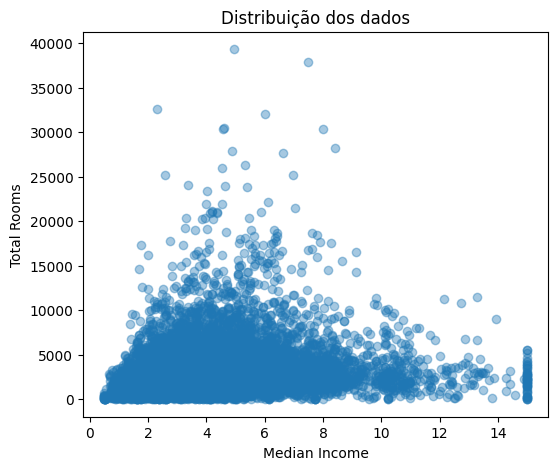

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_cluster['median_income'],
    X_cluster['total_rooms'],
    alpha=0.4
)

plt.xlabel("Median Income")
plt.ylabel("Total Rooms")

plt.title("Distribuição dos dados")

plt.show()

# Índice Calinski-Harabasz

O índice Calinski-Harabasz mede a razão entre:

- dispersão entre clusters
- dispersão dentro dos clusters

$$
CH =
\frac{Tr(B_k)}{Tr(W_k)}
\times
\frac{n-k}{k-1}
$$

onde

- $B_k$ = dispersão entre clusters
- $W_k$ = dispersão interna

Interpretação:

> **Valores maiores indicam clusters melhores.**

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch = calinski_harabasz_score(X_cluster, clusters)

ch

np.float64(29529.70816376591)

# Índice de Silhueta

O índice de silhueta combina coesão e separação.

Para cada ponto:

$$
s(i) =
\frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

onde

- $a(i)$ = distância média dentro do cluster
- $b(i)$ = distância ao cluster mais próximo

Valores possíveis:

- próximo de **1 → clusters bem definidos**
- próximo de **0 → clusters sobrepostos**
- negativo → cluster mal definido

In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_cluster, clusters)

silhouette

np.float64(0.6168720805010625)

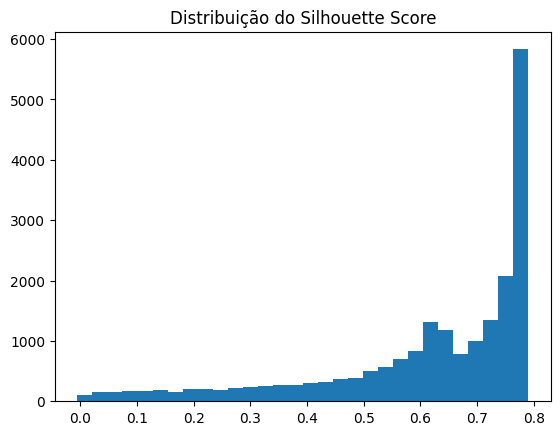

In [ ]:
from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(X_cluster, clusters)

plt.hist(sil_values, bins=30)

plt.title("Distribuição do Silhouette Score")

plt.show()

# Davies-Bouldin Index

Esse índice mede a relação entre:

- dispersão interna
- distância entre clusters

$$
DB =
\frac{1}{K}
\sum_{i=1}^{K}
\max_{j \ne i}
\left(
\frac{s_i + s_j}{d_{ij}}
\right)
$$

Interpretação:

- valores menores indicam clusters melhores

In [ ]:
from sklearn.metrics import davies_bouldin_score

db = davies_bouldin_score(X_cluster, clusters)

db

np.float64(0.5695849311143408)

# Dunn Index

O índice Dunn mede a razão entre:

- menor distância entre clusters
- maior diâmetro dentro de um cluster

$$
Dunn =
\frac{
\min_{i \ne j} d(C_i, C_j)
}{
\max_k diam(C_k)
}
$$

Interpretação:

- valores maiores indicam clusters melhores

In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

def dunn_index(X, labels):

    clusters = np.unique(labels)

    centroids = np.array([X[labels == k].mean(axis=0) for k in clusters])

    intercluster = np.min(cdist(centroids, centroids) + np.eye(len(centroids))*1e9)

    intracluster = np.max([
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in clusters
    ])

    return intercluster / intracluster

dunn = dunn_index(X_cluster.values, clusters)

dunn

np.float64(0.08923828808527713)

In [ ]:
cluster_metrics = pd.DataFrame({

    "WSS":[kmeans.inertia_],
    "Calinski-Harabasz":[ch],
    "Silhouette":[silhouette],
    "Davies-Bouldin":[db],
    "Dunn":[dunn]

})

cluster_metrics

,WSS,Calinski-Harabasz,Silhouette,Davies-Bouldin,Dunn
0,2.507840e+10,29529.708164,0.616872,0.569585,0.089238


Nenhuma métrica isolada determina o melhor clustering.

A escolha do modelo deve considerar simultaneamente:

- coesão
- separação
- estabilidade
- interpretação do domínio